In [1]:
# 1. IMPORT LIBRARIES

import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# 2. LOAD IMDB MOVIE REVIEW DATASET

VOCAB_SIZE = 10000
MAX_LENGTH = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("\nTraining Reviews:", len(X_train))
print("Testing Reviews:", len(X_test))
print("Sentiment Labels: 0 = Negative, 1 = Positive")

# 3. DISPLAY SAMPLE REVIEW

word_index = imdb.get_word_index()
reverse_index = {value + 3: key for key, value in word_index.items()}
reverse_index[0] = "<PAD>"
reverse_index[1] = "<START>"
reverse_index[2] = "<UNK>"
reverse_index[3] = "<UNUSED>"

sample_review = " ".join(reverse_index.get(i, "?") for i in X_train[0])

print("\nSample Review (encoded):", X_train[0][:15])
print("Sample Review (text):", sample_review[:300])
print("Sentiment:", "Positive" if y_train[0] == 1 else "Negative")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training Reviews: 25000
Testing Reviews: 25000
Sentiment Labels: 0 = Negative, 1 = Positive
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step

Sample Review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]
Sample Review (text): <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the
Sentiment: Positive


In [3]:
# 4. PREPROCESS DATA (PADDING)

X_train = pad_sequences(X_train, maxlen=MAX_LENGTH)
X_test = pad_sequences(X_test, maxlen=MAX_LENGTH)

print("\nAfter Padding:")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


After Padding:
Training Data Shape: (25000, 200)
Testing Data Shape: (25000, 200)


In [4]:
# 5. BUILD RNN MODEL

model = Sequential([
    Embedding(VOCAB_SIZE, 32),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.build(input_shape=(None, MAX_LENGTH))

print("\nRNN MODEL:")
model.summary()


RNN MODEL:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,273 (1.24 MB)

 Trainable params: 326,273 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 6. COMPILE MODEL

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 7. TRAIN MODEL

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20,
    verbose=1
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.6414 - loss: 0.6099 - val_accuracy: 0.7466 - val_loss: 0.5180
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7986 - loss: 0.4472 - val_accuracy: 0.6392 - val_loss: 0.6293
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8334 - loss: 0.3803 - val_accuracy: 0.8306 - val_loss: 0.4040
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9002 - loss: 0.2539 - val_accuracy: 0.8344 - val_loss: 0.4222
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9397 - loss: 0.1682 - val_accuracy: 0.7976 - val_loss: 0.4945


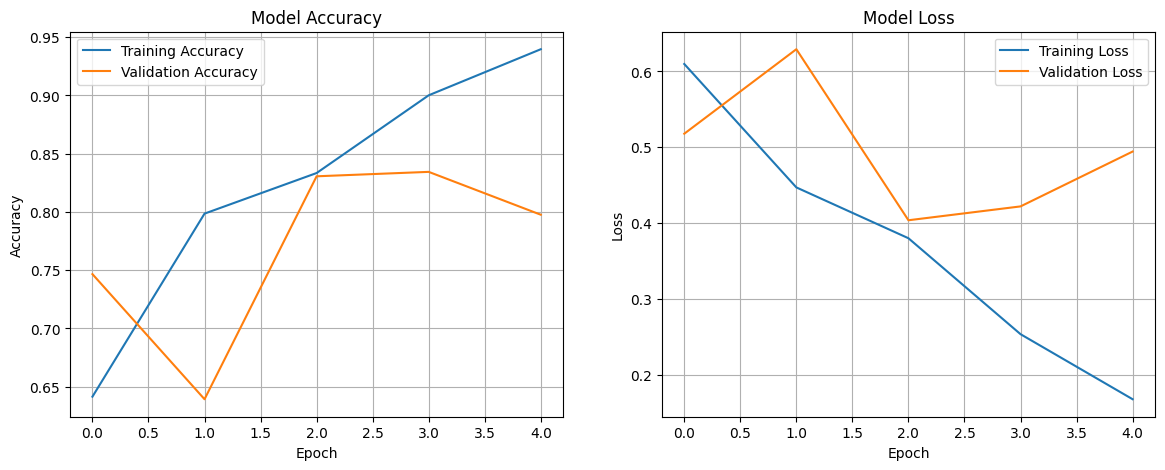

In [6]:
# 8. VISUALIZE TRAINING HISTORY

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


Test Loss: 0.5073
Test Accuracy: 80.07 %

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80     12500
    Positive       0.80      0.81      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000



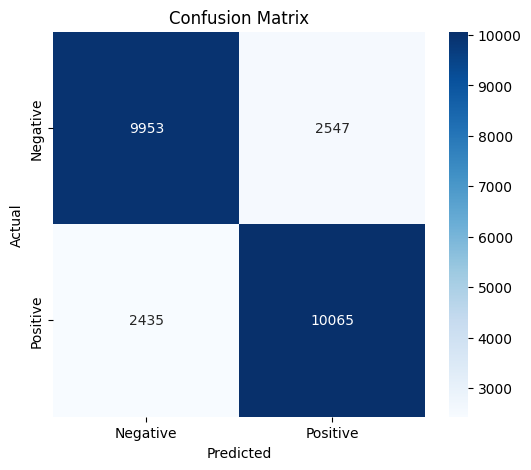

In [7]:
# 9. EVALUATE MODEL

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

# 10. CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
# 11. PREDICT SENTIMENT FOR NEW REVIEWS

def predict_sentiment(text):
    words = re.sub(r"[^a-z\s]", "", text.lower()).split()

    encoded = [1]   # start token
    for word in words:
        index = word_index.get(word)
        if index is not None and index + 3 < VOCAB_SIZE:
            encoded.append(index + 3)
        else:
            encoded.append(2)   # unknown word

    padded = pad_sequences([encoded], maxlen=MAX_LENGTH)
    score = float(model.predict(padded, verbose=0)[0][0])

    label = "Positive" if score > 0.5 else "Negative"
    return label, score

reviews = [
    "This movie was fantastic and the acting was brilliant",
    "The film was boring and a complete waste of time",
    "A wonderful story with great characters and a happy ending",
    "Terrible plot and very bad acting"
]

print("\nSample Predictions:")
print("-" * 60)

for review in reviews:
    label, score = predict_sentiment(review)
    print("Review   :", review)
    print("Sentiment:", label, "| Score:", round(score, 4))
    print("-" * 60)



Sample Predictions:
------------------------------------------------------------
Review   : This movie was fantastic and the acting was brilliant
Sentiment: Negative | Score: 0.1245
------------------------------------------------------------
Review   : The film was boring and a complete waste of time
Sentiment: Negative | Score: 0.0008
------------------------------------------------------------
Review   : A wonderful story with great characters and a happy ending
Sentiment: Negative | Score: 0.353
------------------------------------------------------------
Review   : Terrible plot and very bad acting
Sentiment: Negative | Score: 0.0125
------------------------------------------------------------


In [9]:
# 12. DISPLAY FINAL RESULTS

print("\n===================================")
print("          FINAL RESULT")
print("===================================")

print("RNN Sentiment Analysis model trained successfully.")
print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Review Length:", MAX_LENGTH)
print("Training Reviews:", len(X_train))
print("Testing Reviews:", len(X_test))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")


          FINAL RESULT
RNN Sentiment Analysis model trained successfully.
Vocabulary Size: 10000
Maximum Review Length: 200
Training Reviews: 25000
Testing Reviews: 25000
Test Accuracy: 80.07 %
